# Langevin GLV at the critical point $\mu_c$ — MSB observables (rescaled variables)

Multiplicative-noise (Langevin) GLV on a dense heavy-tailed power-law graph, measured with the same
**rescaled-variable** machinery the other MSB notebooks use, so we can sit *exactly at* the critical
point $\mu_c$ without the absolute abundances overflowing.

**Rescaling.** Write $x_i=M\,y_i$ with $y$ the shape on the simplex ($\sum_i y_i=1$) and $M=\sum_i x_i$
the scale. In rescaled time $\tau$ (with $\mathrm dt_{\rm phys}=\mathrm d\tau/M$) the deterministic GLV
becomes
$$\frac{\mathrm dy_i}{\mathrm d\tau}=y_i\big(F_i-\phi-y_i+\textstyle\sum_j y_j^2\big),\quad
\frac{\mathrm dM}{\mathrm d\tau}=1+M(\phi-\textstyle\sum_j y_j^2),\quad F=Wy,\ \phi=y^\top F.$$
The shape stays bounded and $M$ is tracked separately, so $\mu=\mu_c$ (where $M$ diverges) is fine.

**Langevin noise.** We add multiplicative noise per unit rescaled time, $+\,s\,\mathrm dW_i$ on
$\ln y_i$, projected onto the simplex (subtract the $y$-weighted mean), integrated by Euler--Maruyama.

**MSB measurement.** Reconstruct physical time $t_{\rm phys}(\tau)$, reconstruct the absolute size $S_i=M\,y_i\;(=x_i)$ and resample it on
a uniform **yearly physical-time** grid, growth $g_i=\Delta\ln S_i$, volatility
$\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$. $\mu_c$ is located empirically per realization
(shape-scalar zero-crossing). Operating point: power-law $\alpha=1.5$, $\sigma_{\rm mat}=0.2$, sweep
the noise strength $s$.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skew, kurtosis

import glv
glv.apply_style()

N          = 400
ALPHA      = 1.5          # power-law hidden-degree tail: k = k_min * U^(-1/alpha)
KMIN       = 2.0          # hidden-degree lower cutoff (no upper cap -> heavy tail)
SIGMA_MAT  = 0.2          # interaction-matrix disorder
S_GRID     = np.array([0.02, 0.05, 0.1, 0.2])   # Langevin noise strengths (per unit tau)
dtau       = 0.02         # Euler-Maruyama step in rescaled time
tau_max    = 2.0e4        # rescaled-time horizon
n_years    = 100          # physical-time yearly resample points
n_rec      = 4000         # trajectory samples kept before yearly resampling
n_runs     = 5            # graph realizations pooled per s
FLOOR      = 1e-3         # live-firm threshold for binning
MU_GRID    = np.linspace(-0.2, 0.8, 21)         # grid for the mu_c zero-crossing locator
RES        = "langevin_glv_critical_results.npz"
print(f"Langevin GLV @ mu_c (rescaled) | power-law alpha={ALPHA}, sigma_mat={SIGMA_MAT} "
      f"| noise s in {list(S_GRID)} | dtau={dtau}, tau_max={tau_max:g} | N={N} x {n_runs} runs/s")

Langevin GLV @ mu_c (rescaled) | power-law alpha=1.5, sigma_mat=0.2 | noise s in [np.float64(0.02), np.float64(0.05), np.float64(0.1), np.float64(0.2)] | dtau=0.02, tau_max=20000 | N=400 x 5 runs/s


In [2]:
# Inline dense annealed (Chung-Lu) heavy-tailed power-law graph + interaction matrix.
def sym_noise(N, rng):
    G = rng.standard_normal((N, N))
    B = (G + G.T) / np.sqrt(2.0)
    B[np.diag_indices(N)] = rng.standard_normal(N)
    return B

def build_power_graph(N, alpha, k_min, rng):
    U = rng.uniform(0.0, 1.0, size=N)
    k = k_min * U ** (-1.0 / alpha)                  # heavy-tailed hidden degrees (no cap)
    C = float(k.mean())
    outer = np.outer(k, k)
    P = outer / (outer + N * C)
    A = P + np.sqrt(P * (1.0 - P)) * sym_noise(N, rng)
    A[np.diag_indices(N)] = 0.0
    return k, C, A

def build_W(A, C, mu, sigma, B):
    return A * ((mu / C) + (sigma / np.sqrt(C)) * B)

In [3]:
# Empirical mu_c: relax the rescaled shape, read c = y*^T W y* - y*^T y* (sign of dM/dtau = 1 + cM),
# take the zero-crossing of c(mu). An m_cap event keeps supercritical runs from overflowing.
def shape_scalar_c(W, tau=1e4, m_cap=1e250):
    def rhs(t, st):
        y = np.clip(st[:N], 0.0, None); M = st[N]
        tot = y.sum()
        if tot > 0: y = y / tot
        F = W @ y; phi = y @ F; sq = y @ y
        dM = 0.0 if M >= m_cap else 1.0 + M * (phi - sq)
        return np.concatenate((y * (F - phi - y + sq), [dM], [1.0 / M]))
    def cap(t, st): return st[N] - m_cap
    cap.terminal = True; cap.direction = 1
    s0 = np.concatenate((np.full(N, 1.0 / N), [1.0], [0.0]))
    sol = solve_ivp(rhs, (0.0, tau), s0, method="LSODA", rtol=1e-8, atol=1e-10,
                    events=cap, t_eval=[tau])
    final = np.asarray(sol.y_events[0])[-1] if sol.t_events[0].size > 0 else sol.y[:, -1]
    y = np.clip(np.asarray(final).ravel()[:N], 0.0, None); y = y / y.sum()
    return float(y @ (W @ y) - y @ y)

def locate_mu_c(A, C, B, mus):
    cs = np.array([shape_scalar_c(build_W(A, C, m, SIGMA_MAT, B)) for m in mus])
    cross = np.where(np.diff(np.sign(cs)))[0]
    if cross.size == 0:
        return np.nan
    i = cross[0]
    return float(mus[i] - cs[i] * (mus[i + 1] - mus[i]) / (cs[i + 1] - cs[i]))

In [4]:
# Rescaled Langevin GLV, Euler-Maruyama in tau. State: shape y (simplex), scale M, physical time t.
# Multiplicative noise per unit tau on ln y, projected onto the simplex. MSB uses the ABSOLUTE size
# S_i = M*y_i (= x_i): we record log S = ln M + ln y at each physical-time sample (never forms the
# huge number itself, so it stays finite even as M grows at mu_c).
def integrate_rescaled(W, s, seed):
    rng = np.random.default_rng(seed)
    y = np.full(N, 1.0 / N, dtype=np.float64)
    M = 1.0; t_phys = 0.0
    nstep = int(tau_max / dtau)
    sdt = s * np.sqrt(dtau)
    rec_every = max(nstep // n_rec, 1)
    ts, LS = [], []
    for n in range(nstep):
        F = W @ y
        phi = float(y @ F); sq = float(y @ y)
        xi = rng.standard_normal(N); xi = xi - float(y @ xi)        # project noise onto simplex
        u = np.log(y) + (F - phi - y + sq) * dtau + sdt * xi
        u -= u.max(); y = np.exp(u); y /= y.sum()
        M = M + (1.0 + M * (phi - sq)) * dtau
        if not np.isfinite(M) or M <= 0:
            break
        t_phys = t_phys + dtau / M
        if n % rec_every == 0:
            ts.append(t_phys); LS.append(np.log(M) + np.log(y))      # ln S_i = ln(M y_i)
    ts = np.array(ts); logS = np.array(LS, dtype=np.float64).T        # (N, T) in physical time
    assert np.isfinite(logS).all()
    return ts, logS

In [5]:
# MSB observables from the absolute size S=M*y: resample ln S on a uniform yearly physical-time grid,
# growth g = Delta ln S, volatility sigma_i = sqrt(pi/2) mean|g - gbar|; size = time-average S_i.
def observables(ts, logS):
    if ts.size < 5 or ts[-1] <= ts[0]:
        return None
    dt = (ts[-1] - ts[0]) / n_years
    tyr = np.arange(ts[0], ts[-1], dt)
    LSr = np.array([np.interp(tyr, ts, logS[k]) for k in range(N)])
    g = np.diff(LSr, axis=1)
    g_bar = g.mean(axis=1, keepdims=True)
    vol = np.sqrt(np.pi / 2.0) * np.mean(np.abs(g - g_bar), axis=1)
    avg = np.exp(LSr).mean(axis=1)                                    # time-average absolute size
    return avg, vol, g.ravel(), float(ts[-1])

if os.path.exists(RES):
    d = np.load(RES, allow_pickle=True)
    by_s = d["by_s"].item()
    print(f"loaded cache {RES}")
else:
    by_s = {float(s): {"avg": [], "vol": [], "g": [], "mu_c": [], "tphys": [], "dropped": 0} for s in S_GRID}
    for r in range(n_runs):
        seed = 7000 + r
        rng = np.random.default_rng(seed)
        k, C, A = build_power_graph(N, ALPHA, KMIN, rng)
        B = sym_noise(N, rng)
        mc = locate_mu_c(A, C, B, MU_GRID)
        W = build_W(A, C, mc, SIGMA_MAT, B)          # sit exactly at the located mu_c
        print(f"run {r}: <k>={C:.2f}, mu_c={mc:.3f}")
        for s in S_GRID:
            ts, logS = integrate_rescaled(W, float(s), seed + 1)
            res = observables(ts, logS)
            if res is None:
                by_s[float(s)]["dropped"] += 1
                print(f"    s={s:g}: dropped (no physical-time window)"); continue
            a, v, gg, tend = res
            dd = by_s[float(s)]
            dd["avg"].append(a); dd["vol"].append(v); dd["g"].append(gg)
            dd["mu_c"].append(mc); dd["tphys"].append(tend)
            print(f"    s={s:g}: t_phys={tend:.1f}, vol[med]={np.median(v):.3f}")
    for s in by_s:
        for key in ("avg", "vol", "g"):
            by_s[s][key] = np.concatenate(by_s[s][key]) if by_s[s][key] else np.array([])
    np.savez(RES, by_s=np.array(by_s, dtype=object))
    print(f"saved {RES}")

run 0: <k>=5.12, mu_c=0.334


    s=0.02: t_phys=13.8, vol[med]=0.206


    s=0.05: t_phys=32.8, vol[med]=0.641


    s=0.1: t_phys=105.6, vol[med]=1.331


    s=0.2: t_phys=396.5, vol[med]=2.684


...

run 4: <k>=5.83, mu_c=0.302


    s=0.02: t_phys=13.6, vol[med]=0.202


    s=0.05: t_phys=32.4, vol[med]=0.645


    s=0.1: t_phys=104.7, vol[med]=1.320


    s=0.2: t_phys=394.5, vol[med]=2.665
saved langevin_glv_critical_results.npz


In [6]:
def vbin(x, y, nb=22):
    o = np.argsort(x); xp, yp = x[o], y[o]
    parts = np.array_split(np.arange(xp.size), nb)
    return (np.array([xp[p].mean() for p in parts]), np.array([np.median(yp[p]) for p in parts]))

def beta_fit(x, y):
    bx, by = vbin(x, y)
    return np.polyfit(np.log10(bx), np.log10(by), 1)[0]

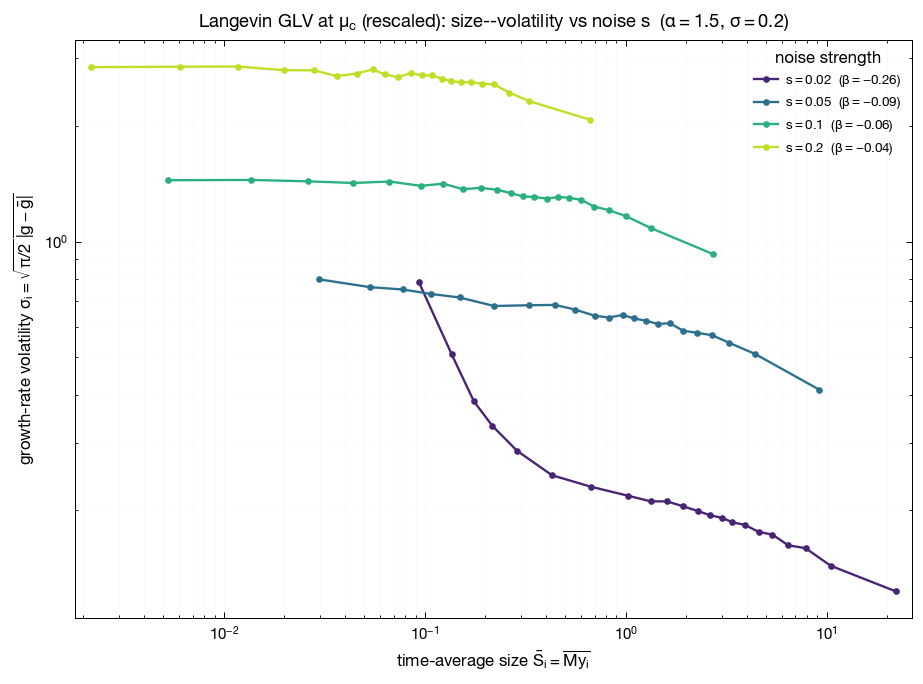

In [7]:
# Plot 1: size-volatility relation at mu_c, one V-curve per noise strength s.
fig, ax = plt.subplots(figsize=(7.8, 5.8))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(S_GRID)))
for s, col in zip(sorted(by_s), cmap):
    b = by_s[s]
    if b["avg"].size == 0:
        continue
    live = (b["avg"] > FLOOR) & (b["vol"] > 0) & np.isfinite(b["vol"])
    if live.sum() < 50:
        continue
    bx, by = vbin(b["avg"][live], b["vol"][live])
    beta = beta_fit(b["avg"][live], b["vol"][live])
    ax.loglog(bx, by, "o-", ms=4, color=col, label=rf"$s={s:g}$  ($\beta={beta:+.2f}$)")
ax.set(xlabel=r"time-average size $\bar S_i=\overline{M y_i}$",
       ylabel=r"growth-rate volatility $\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$",
       title=rf"Langevin GLV at $\mu_c$ (rescaled): size--volatility vs noise $s$  "
             rf"($\alpha={ALPHA}$, $\sigma={SIGMA_MAT}$)")
ax.grid(True, which="both", alpha=0.15)
ax.legend(fontsize=8, title="noise strength")
plt.tight_layout()
plt.savefig("langevin_glv_critical_volatility_size.png", dpi=120)
plt.show()

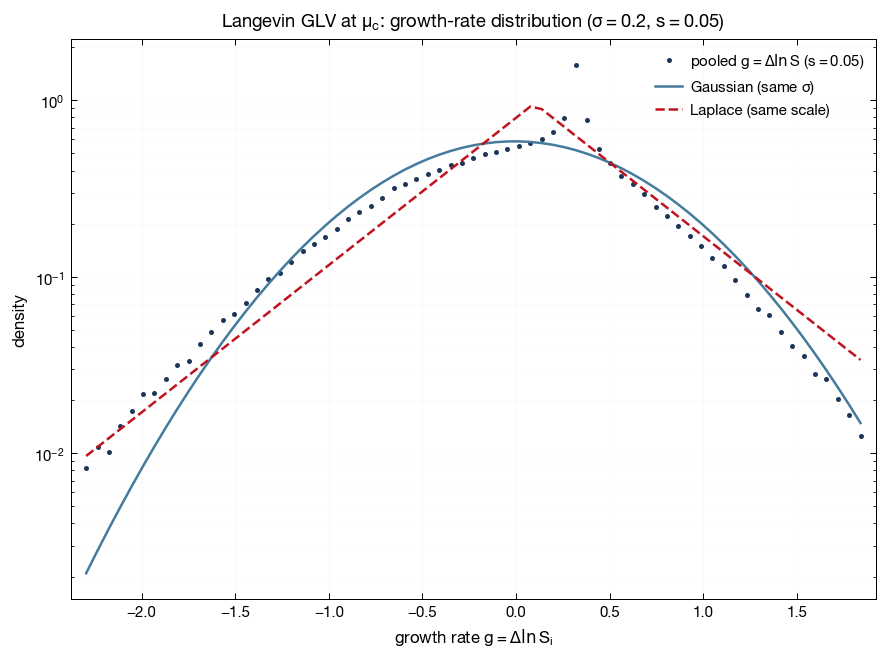

s=0.02: beta=-0.261  skew=-4.32  exkurt=+38.60  t_phys[med]=13.6  mu_c[med]=0.308
s=0.05: beta=-0.090  skew=-0.48  exkurt=+1.10  t_phys[med]=32.4  mu_c[med]=0.308
s=0.1: beta=-0.057  skew=-0.12  exkurt=+0.19  t_phys[med]=104.7  mu_c[med]=0.308
s=0.2: beta=-0.043  skew=-0.04  exkurt=+0.12  t_phys[med]=393.1  mu_c[med]=0.308


In [8]:
# Plot 2: pooled growth-rate distribution at a representative s.
s_show = 0.05 if 0.05 in by_s else sorted(by_s)[0]
g = by_s[s_show]["g"]; g = g[np.isfinite(g)]
mu_g, sd_g, med_g = g.mean(), g.std(), np.median(g)
b_lap = np.mean(np.abs(g - med_g))
lo, hi = np.percentile(g, [0.3, 99.7])
edges = np.linspace(lo, hi, 70); centers = 0.5 * (edges[:-1] + edges[1:])
dens, _ = np.histogram(g, bins=edges, density=True)
gauss = np.exp(-0.5 * ((centers - mu_g) / sd_g) ** 2) / (sd_g * np.sqrt(2 * np.pi))
lap = np.exp(-np.abs(centers - med_g) / b_lap) / (2 * b_lap)
fig, ax = plt.subplots(figsize=(7.5, 5.6))
ax.semilogy(centers, np.where(dens > 0, dens, np.nan), "o", ms=3, color="#1d3557",
            label=rf"pooled $g=\Delta\ln S$ ($s={s_show:g}$)")
ax.semilogy(centers, gauss, "-", color="#457b9d", lw=1.5, label=r"Gaussian (same $\sigma$)")
ax.semilogy(centers, lap, "--", color="#c1121f", lw=1.5, label="Laplace (same scale)")
ax.set(xlabel=r"growth rate $g=\Delta\ln S_i$", ylabel="density",
       title=rf"Langevin GLV at $\mu_c$: growth-rate distribution ($\sigma={SIGMA_MAT}$, $s={s_show:g}$)")
ax.grid(True, which="both", alpha=0.15)
ax.legend()
plt.tight_layout()
plt.savefig("langevin_glv_critical_growth_dist.png", dpi=120)
plt.show()
for s in sorted(by_s):
    b = by_s[s]; g = b["g"]; g = g[np.isfinite(g)]
    if g.size == 0:
        print(f"s={s}: dropped={b['dropped']}"); continue
    live = (b["avg"] > FLOOR) & (b["vol"] > 0) & np.isfinite(b["vol"])
    print(f"s={s}: beta={beta_fit(b['avg'][live], b['vol'][live]):+.3f}  skew={skew(g):+.2f}  "
          f"exkurt={kurtosis(g):+.2f}  t_phys[med]={np.median(b['tphys']):.1f}  mu_c[med]={np.median(b['mu_c']):.3f}")

## Summary — MSB at $\mu_c$ from the absolute size $S=M y$ ($\sigma=0.2$)

Measured exactly at the critical point $\mu_c$ (rescaled shape+scale machinery; $\mu_c\approx0.30$
per realization), with the MSB observables built from the **absolute** size $S_i=M y_i\,(=x_i)$ — so
growth $g_i=\Delta\ln S_i=\Delta\ln M+\Delta\ln y_i$ includes the common-mode (overall/market)
growth, not just the composition.

| $s$ | $\beta$ (size--vol) | skew | excess kurtosis | $t_{\rm phys}$ |
|---|---|---|---|---|
| 0.02 | $-0.26$ | $-4.32$ | 38.6 | 13.6 |
| 0.05 | $-0.09$ | $-0.48$ | 1.10 | 32 |
| 0.10 | $-0.06$ | $-0.12$ | 0.19 | 105 |
| 0.20 | $-0.04$ | $-0.04$ | 0.12 | 393 |

- The size--volatility law **declines** ($\beta<0$) at every noise level, but is **shallow** in the
  stationary regime ($\beta\approx-0.04\text{ to }-0.09$ for $s\ge0.05$). It is shallower than the
  composition-only $S=N y$ version because the common-mode $\Delta\ln M$ is identical across firms
  and adds a **size-independent volatility floor**, flattening the slope.
- **Growth distribution** ($s=0.05$): tent-shaped / Laplace-like, fat-tailed (excess kurtosis
  $\approx1.1$) and now **left-skewed** ($-0.48$) — the common-mode market growth is one-sided.
- **Lowest noise $s=0.02$:** $\beta$ steepens to $-0.26$ with heavy tails, but skew $-4.3$ over a
  very short window ($t_{\rm phys}\approx14$) marks the one-sided **relaxation transient** (the
  collective $M$-growth dominating), not stationary MSB.

**Bottom line.** At $\mu_c$, $\sigma=0.2$, the absolute-size MSB shows a genuine but **weak**
declining size--volatility law ($\beta\approx-0.05$ stationary) plus a tent-shaped, left-skewed,
fat-tailed growth distribution. The common-mode market growth both flattens $\beta$ and skews the
growth left. $\sigma=0.2$ is near the floor of where this heavy-tail GLV imprints MSB; the strongest
slope sits in the transient corner. (Noise added per unit rescaled time $\tau$.)